# NFL Kaggle Data 2026: Exploratory Data Analysis

## Introduction

In this notebook we will explore the data in Kaggle's NFL Data 2026. This is for us to know how to build the model and how the data would be distributed.

We will firstly import all our dependencies. We will be using seaborn to visualise graph.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

Next we will use the training dataset to collect distributions. We will use 2023 week01 input and output. Note that this could be changed to the other training datasets.

In [3]:
df = pd.read_csv("train/input_2023_w01.csv")
df_out = pd.read_csv("train/output_2023_w01.csv")

## General Data Overview

### Data shape and type

Here are the general information for the dataset. Shape of it, and datatypes of the columns. As mentioned in the dataset for 2023 week 1, there are 285714 recorded frames, and 23 columns. 

From kaggle, these are the meaning of each column :
- game_id: Game identifier, unique (numeric)
- play_id: Play identifier, not unique across games (numeric)
- player_to_predict: whether or not the x/y prediction for this player will be scored (bool)
- nfl_id: Player identification number, unique across players (numeric)
- frame_id: Frame identifier for each play/type, starting at 1 for each game_id/play_id/file type (input or output) (numeric)
- play_direction: Direction that the offense is moving (left or right)
- absolute_yardline_number: Distance from end zone for possession team (numeric)
- player_name: player name (text)
- player_height: player height (ft-in)
- player_weight: player weight (lbs)
- player_birth_date: birth date (yyyy-mm-dd)
- player_position: the player's position (the specific role on the field that they typically play)
- player_side: team player is on (Offense or Defense)
- player_role: role player has on play (Defensive Coverage, Targeted Receiver, Passer or Other Route Runner)
- x: Player position along the long axis of the field, generally within 0 - 120 yards. (numeric)
- y: Player position along the short axis of the field, generally within 0 - 53.3 yards. (numeric)
- s: Speed in yards/second (numeric)
- a: Acceleration in yards/second^2 (numeric)
- o: orientation of player (deg)
- dir: angle of player motion (deg)
- num_frames_output: Number of frames to predict in output data for the given game_id/play_id/nfl_id. (numeric)
- ball_land_x: Ball landing position position along the long axis of the field, generally within 0 - 120 yards. (numeric)
- ball_land_y: Ball landing position along the short axis of the field, generally within 0 - 53.3 yards. (numeric)

In [4]:
print("General Info for Input Data:")
print("Data shape: ", df.shape)
print(df.dtypes)

General Info for Input Data:
Data shape:  (285714, 23)
game_id                       int64
play_id                       int64
player_to_predict              bool
nfl_id                        int64
frame_id                      int64
play_direction               object
absolute_yardline_number      int64
player_name                  object
player_height                object
player_weight                 int64
player_birth_date            object
player_position              object
player_side                  object
player_role                  object
x                           float64
y                           float64
s                           float64
a                           float64
dir                         float64
o                           float64
num_frames_output             int64
ball_land_x                 float64
ball_land_y                 float64
dtype: object


### Feature Correlation

Upon doing research on exploratory data analysis, I have found that feature correlation graph could reveal helpful, hidden information. My research had showed that the quickest way to find feature correlation is by matching it in a matrix and calculating their similarity score.

I had done this by using a seaborn heatmap with red representing higher similarity scores. To calculate correlation (similarity) I had used the Pearson's correlation coefficient (in the code corr = df[features].corr() in which Pearson's is the default) :
$$r = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum(x_i - \bar{x})^2 \cdot \sum(y_i - \bar{y})^2}}$$

- Ranges from -1 (perfect negative) to +1 (perfect positive)
- Values near 0 indicate no linear relationship

From the result I had gotten, I had found that :
- x is closely correlated to absolute yardline number
- x is also closely correlated to ball_land_x

This phenomenon could easily be explained intuitively because the player's x location on the field's length wise will always be in line the ball landing's x position. Meanwhile, the fact that x is closely correlated to the absolute yardline number (the distance from the passer's team to the goal) could allow us to guess that most passes are towards the direction of the goal.

Furthermore, the fact that the y position of the player has less correlation to the y position of the ball landing could help us guess that most receivers spread laterally across the field rather than tracking directly to the ball's landing y position, suggesting routes are designed to create separation rather than mirror the ball's trajectory.

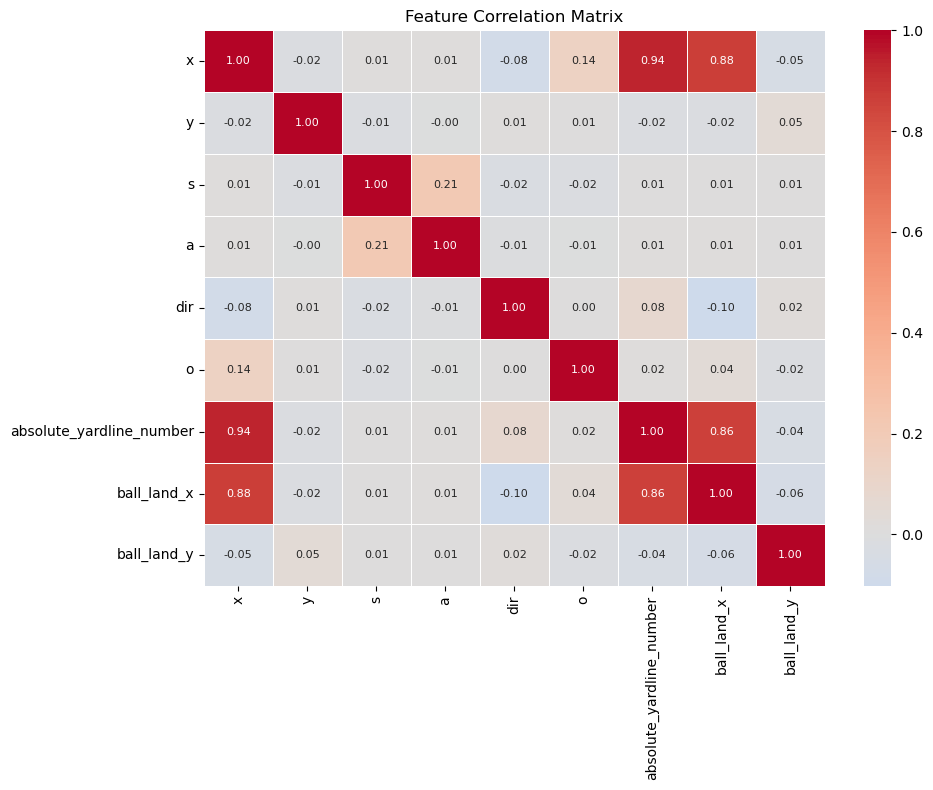

In [6]:
features = ["x", "y", "s", "a", "dir", "o",
            "absolute_yardline_number", "ball_land_x", "ball_land_y"]

corr = df[features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, annot_kws={"size": 8})
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

### Data distribution 

Frames per player per play. This data is not generally very important, as it just shows what the average amount of data is recorded for each player per play. Of course, during each play, every player in that play has the same amount of recorded frames. 

As shown in this data, the must be at least 9 frames recorded, while at most 70+ frames per play. In average, there are 30 frames recorded per play.

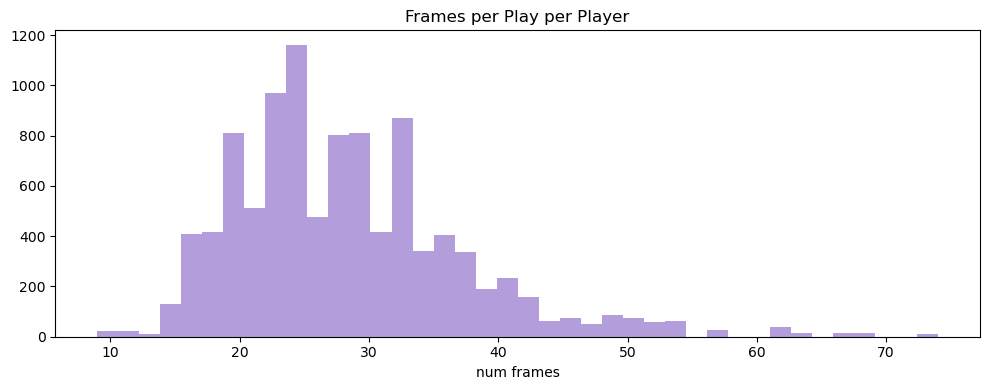

In [7]:
frames_per_play = df.groupby(["game_id", "play_id", "nfl_id"])["frame_id"].max()

plt.figure(figsize=(10, 4))
plt.hist(frames_per_play, bins=40, color="#b39ddb", edgecolor="none")
plt.title("Frames per Play per Player")
plt.xlabel("num frames")
plt.tight_layout()
plt.show()

## Investigating Factors that affects our prediction (Key EDA)

### Ball landing distribution

Intuitively, attack receivers move towards the ball, while other attackers move depends on tactics. Defense will almost always move with attackers. Thus, if most of the ball landing distribution is on one area, model could be skewed.

We will generate the locations of wherever the ball lands. I wanted to how the ball landing is distributed generally and found that it is relatively spreadout with more plays in the middle. This is one of the most crucial factors that dictate where the players end up in our prediction. 

The distribution presents that data might be skewed to the middle for this week's dataset, if a model only uses this week.

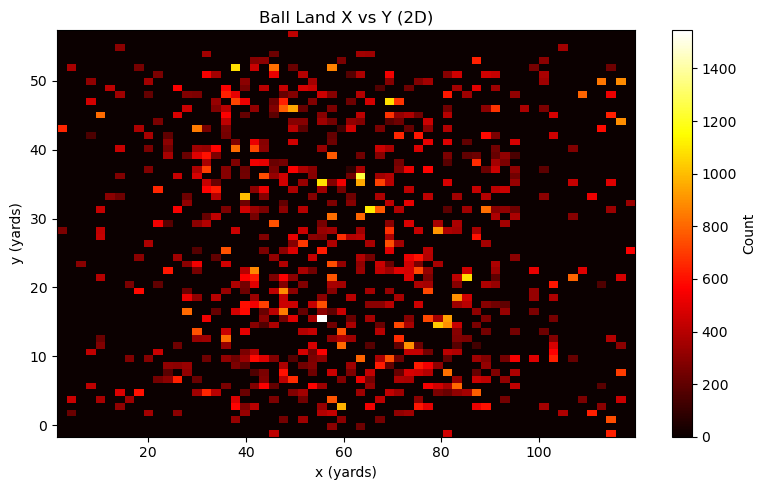

In [8]:
plt.figure(figsize=(8, 5))
plt.hist2d(
    df["ball_land_x"].dropna(), df["ball_land_y"].dropna(),
    bins=60, cmap="hot"
)
plt.colorbar(label="Count")
plt.title("Ball Land X vs Y (2D)")
plt.xlabel("x (yards)")
plt.ylabel("y (yards)")
plt.tight_layout()
plt.show()


### Player Roles

The next factor we could be considering in our player movement prediction is the player roles. Some player roles are filled by fast players, while others are filled by slow but strong players. Firstly, we want to count how many player's data is recorded based on player role. As we believe, one of the factors that affects the prediction is the player role.

This distribution describes that there are more data for defensive coverage roles than any other roles, with the passer's data being the least recorded. This makes sense, as once the ball is in the air only the information for the defensive coverage for the defense and the route runner with the receiver for the offense is important, as the passer is unlikely to be the one intercepting or receiving his own pass (while the ball is on the air). 

Moreover, there will be more information from the defensive coverage, as opposed to the receiver as there could be multiple people defending the pass as opposed to the 1 guy receiving it.

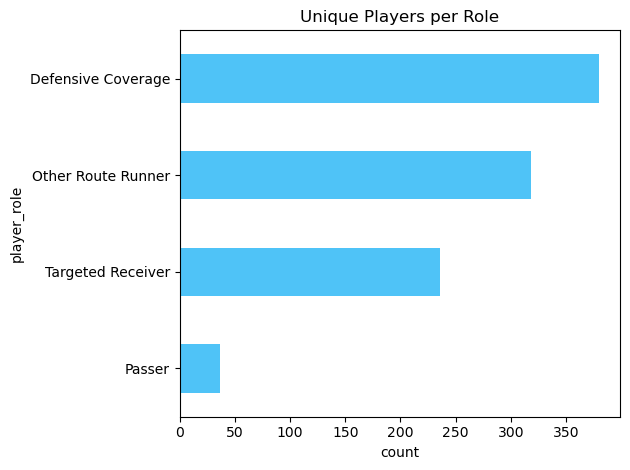

In [9]:
df.groupby("player_role")["nfl_id"].nunique().sort_values().plot(
    kind="barh", color="#4fc3f7"
)
plt.title("Unique Players per Role")
plt.xlabel("count")
plt.tight_layout()
plt.show()

In order to find speed and acceleration distirbution, taking the mean of the speed and acceleration throughout the data, for each game or even for each play would not be very efficient.Hence, if we could figure out speed and acceleration based on player roles, we could discern how much player roles affect, how far player moves.

The distribution showed us that the targeted receiver and the other route runner has the highest speed and acceleration in these scenarios, while the passer has the least. This allows us to conclude that when a pass is made, it is towards the direction of the defense (since they do not have to run as fast to get to the same location) meaning the defense will always be the closest to the absolute yard point. 

Furthermore, after the pass is made, it can be concluded that in the offense, the passer will not move as much, while the receiver and the other route runner will run the most while the ball is in the air. This allows our model to predict higher speed and acceleration for those two roles.

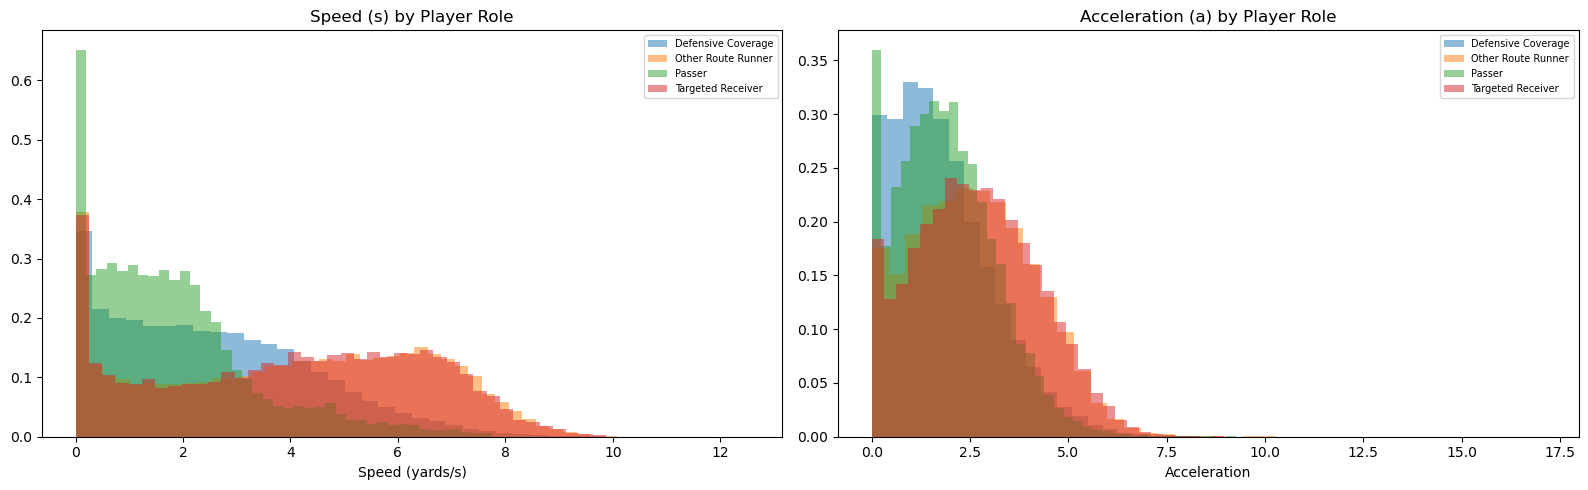

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for role, grp in df.groupby("player_role"):
    axes[0].hist(grp["s"].dropna(), bins=40, alpha=0.5, label=role, density=True)
    axes[1].hist(grp["a"].dropna(), bins=40, alpha=0.5, label=role, density=True)

axes[0].set_title("Speed (s) by Player Role")
axes[0].set_xlabel("Speed (yards/s)")
axes[0].legend(fontsize=7)

axes[1].set_title("Acceleration (a) by Player Role")
axes[1].set_xlabel("Acceleration")
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()

The third factor that could affect player movement prediction is their rate of turning, again based on role. 
Note that by taking the difference in speed per frame, we could determine the rate of turning.

In the delta speed graph, a +1 indicates a positive change in speed (gets faster) while a -1 is a deceleration, while in the delta direction graph a -40 indicates a 40 degree trun counterclockwise and +40 represents clockwise direction change.

In this plot, we could conclude that players do not turn much in their trajectory, and that the receiver accelerates the most.

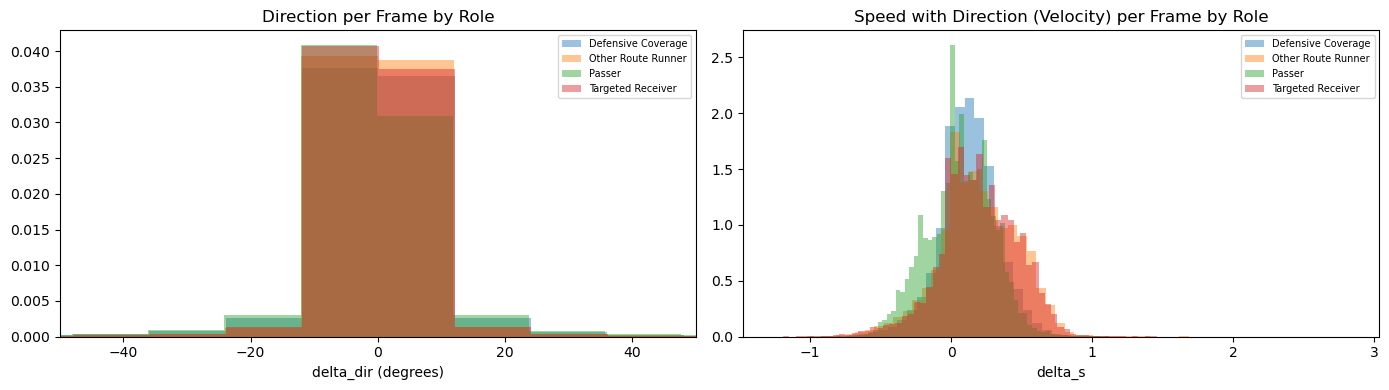

In [11]:
df = df.sort_values(["game_id", "play_id", "nfl_id", "frame_id"])
df["delta_dir"] = df.groupby(["game_id", "play_id", "nfl_id"])["dir"].diff()
df["delta_s"]   = df.groupby(["game_id", "play_id", "nfl_id"])["s"].diff()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for role, grp in df.groupby("player_role"):
    axes[0].hist(grp["delta_dir"].dropna(), bins=60, alpha=0.45, label=role, density=True)
    axes[1].hist(grp["delta_s"].dropna(),   bins=60, alpha=0.45, label=role, density=True)

axes[0].set_title("Direction per Frame by Role")
axes[0].set_xlabel("delta_dir (degrees)")
axes[0].set_xlim(-50, 50)
axes[0].legend(fontsize=7)

axes[1].set_title("Speed with Direction (Velocity) per Frame by Role")
axes[1].set_xlabel("delta_s")
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()

Distance from ball alnding based on player role. This is arguably one of the more important distributions. Earlier, we had discerned that most players will be laterally at the same position (close x coordinate correlation to the ball landing), while this is not true for the y axis. 

THis distribution helps us discern how separated the roles are from each other, and allows the model to predict the positions of the players to be skewed towards this value. As expected, the tareted receiver has the least distance to the ball, while the defense coverage is the second closest to the ball. This means that more often than not the receiver catches the ball (when the distance from ball to receiver = 0).

The other route runner will be the furthest away from the ball to diffuse the defense.

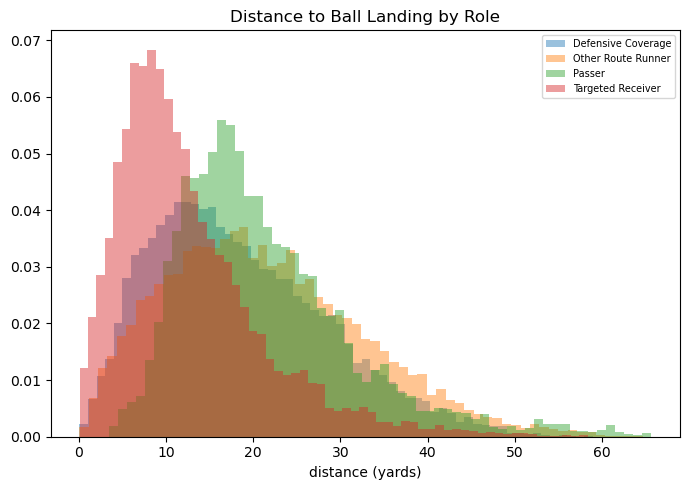

In [14]:
df["dist_to_ball_x"] = df["ball_land_x"] - df["x"]
df["dist_to_ball_y"] = df["ball_land_y"] - df["y"]
df["dist_to_ball"]   = np.sqrt(df["dist_to_ball_x"]**2 + df["dist_to_ball_y"]**2)

fig, axes = plt.subplots(1, 1, figsize=(7, 5))

for role, grp in df.groupby("player_role"):
    axes.hist(grp["dist_to_ball"].dropna(), bins=60,
              alpha=0.45, label=role, density=True)

axes.set_title("Distance to Ball Landing by Role")
axes.set_xlabel("distance (yards)")
axes.legend(fontsize=7)

plt.tight_layout()
plt.show()

## Insights

### What we can change for our models?

## Conclusion

In conclusion, we will use player role and ball landing to predict. and we are using GNN.